In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/2025AA05663_ml_assignment"
folders = ["data", "model", "outputs"]

os.makedirs(BASE_DIR, exist_ok=True)
for f in folders:
    os.makedirs(os.path.join(BASE_DIR, f), exist_ok=True)

print("Project folder at:", BASE_DIR)
print("Folder contains:", os.listdir(BASE_DIR))


Project folder at: /content/drive/MyDrive/2025AA05663_ml_assignment
Folder contains: ['data', 'models', 'outputs']


In [ ]:
!wget -O credit_default.xls https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls


--2026-02-14 12:49:19--  https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘credit_default.xls’

credit_default.xls      [   <=>              ]   5.28M  10.8MB/s    in 0.5s    

2026-02-14 12:49:20 (10.8 MB/s) - ‘credit_default.xls’ saved [5539328]



In [ ]:
!pip -q install xlrd==2.0.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 2.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_excel("credit_default.xls", header=1)
print("Shape:", df.shape)
df.head()


Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
# Dropping ID column
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# Renaming target column
target_col = "default payment next month"
df = df.rename(columns={target_col: "target"})

print("Final Shape:", df.shape)
print("Target distribution:")
print(df["target"].value_counts())


Final Shape: (30000, 24)
Target distribution:
target
0    23364
1     6636
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=["target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (30000, 23)
y shape: (30000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))


Train shape: (24000, 23) (24000,)
Test shape: (6000, 23) (6000,)

Train target distribution:
target
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Test target distribution:
target
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [ ]:
!pip -q install xgboost
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),

    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=80,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=120,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}


In [ ]:
print("Total models:", len(models))
print(list(models.keys()))


Total models: 6
['Logistic Regression', 'Decision Tree', 'KNN', 'Naive Bayes', 'Random Forest', 'XGBoost']


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)
import pandas as pd


In [ ]:
def evaluate_classifier(model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

    conf_matrix = confusion_matrix(y_test, y_pred)

    return metrics, conf_matrix


In [ ]:
results = []
conf_matrices = {}

for model_name, model in models.items():
    print(f"Training: {model_name}")

    model.fit(X_train, y_train)

    metrics, cm = evaluate_classifier(model, X_test, y_test)

    row = {"ML Model Name": model_name}
    row.update(metrics)

    results.append(row)
    conf_matrices[model_name] = cm


Training: Logistic Regression
Training: Decision Tree
Training: KNN
Training: Naive Bayes
Training: Random Forest
Training: XGBoost


In [ ]:
metrics_df = pd.DataFrame(results)
metrics_df = metrics_df[
    ["ML Model Name", "Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]
]

metrics_df


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.807667,0.707636,0.686825,0.239638,0.355307,0.324443
1,Decision Tree,0.714500,0.607451,0.369418,0.411454,0.389305,0.204216
2,KNN,0.800333,0.709969,0.581957,0.345139,0.433302,0.337766
3,Naive Bayes,0.752500,0.724930,0.451474,0.553881,0.497462,0.338620
4,Random Forest,0.816000,0.772717,0.657709,0.350414,0.457227,0.384417
5,XGBoost,0.817000,0.778084,0.660589,0.354936,0.461765,0.388812


In [ ]:
metrics_df.to_csv("metrics_comparison.csv", index=False)
print("Saved modelmetrics_comparison.csv")


Saved modelmetrics_comparison.csv


In [ ]:
!pip -q install joblib


In [ ]:
import os
import joblib

os.makedirs("model", exist_ok=True)

for model_name, model in models.items():
    file_name = model_name.lower().replace(" ", "_").replace("-", "_")
    path = f"model/{file_name}.pkl"
    joblib.dump(model, path)
    print("Saved:", path)


Saved: model/logistic_regression.pkl
Saved: model/decision_tree.pkl
Saved: model/knn.pkl
Saved: model/naive_bayes.pkl
Saved: model/random_forest.pkl
Saved: model/xgboost.pkl


In [ ]:
metrics_df.to_csv("metrics_comparison.csv", index=False)
print("Saved metrics_comparison.csv")


Saved metrics_comparison.csv


In [ ]:
loaded_model = joblib.load("model/xgboost.pkl")

sample_preds = loaded_model.predict(X_test.iloc[:10])
sample_probs = loaded_model.predict_proba(X_test.iloc[:10])[:, 1]

print("Predictions:", sample_preds)
print("Probabilities:", sample_probs)


Predictions: [0 0 0 0 0 1 0 0 0 0]
Probabilities: [0.16149032 0.09557337 0.155928   0.17301239 0.02655359 0.7131458
 0.1091875  0.03719461 0.10978276 0.08614374]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


In [ ]:
def plot_confusion_matrix(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, values_format="d")

    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()

    return fig


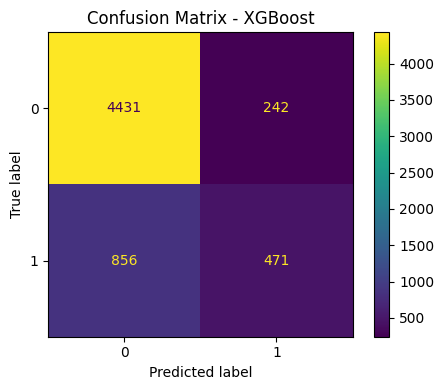

In [ ]:
fig = plot_confusion_matrix(models["XGBoost"], X_test, y_test, "XGBoost")
plt.show()


In [ ]:
def get_classification_report(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return classification_report(y_test, y_pred, output_dict=True)


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import os

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ---------------------------
# Page Config
# ---------------------------
st.set_page_config(
    page_title="Credit Default Prediction",
    layout="wide"
)

st.title("ML Assignment : Credit Card Default Prediction")
st.write(
    "Select a trained model and upload a test CSV file to generate predictions and evaluate performance."
)

# ---------------------------
# Paths
# ---------------------------
MODEL_DIR = "model"
SAMPLE_DIR = "sample_data"

MODEL_FILES = {
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "KNN": "knn.pkl",
    "Naive Bayes": "naive_bayes.pkl",
    "Random Forest": "random_forest.pkl",
    "XGBoost": "xgboost.pkl"
}

SAMPLE_FILES = {
    "Sample CSV (with target)": "test_with_target.csv",
    "Sample CSV (without target)": "test_without_target.csv"
}

# ---------------------------
# Load model
# ---------------------------
@st.cache_resource
def load_model(model_name: str):
    model_path = os.path.join(MODEL_DIR, MODEL_FILES[model_name])
    return joblib.load(model_path)

# ---------------------------
# Metrics + Confusion Matrix
# ---------------------------
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

def confusion_matrix_figure(y_true, y_pred, title_text):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, values_format="d")
    ax.set_title(title_text)
    plt.tight_layout()
    return fig

# ---------------------------
# Sidebar Controls
# ---------------------------
st.sidebar.header("Inputs")

model_key = st.sidebar.selectbox("Choose a model", list(MODEL_FILES.keys()))
model = load_model(model_key)

uploaded_file = st.sidebar.file_uploader("Upload CSV (test data)", type=["csv"])

# ---------------------------
# Sample CSV Download Section
# ---------------------------
st.subheader("Download Sample Test Files")

col1, col2 = st.columns(2)

for i, (label, fname) in enumerate(SAMPLE_FILES.items()):
    sample_path = os.path.join(SAMPLE_DIR, fname)

    if os.path.exists(sample_path):
        with open(sample_path, "rb") as f:
            data = f.read()

        if i == 0:
            with col1:
                st.download_button(
                    label=label,
                    data=data,
                    file_name=fname,
                    mime="text/csv"
                )
        else:
            with col2:
                st.download_button(
                    label=label,
                    data=data,
                    file_name=fname,
                    mime="text/csv"
                )
    else:
        st.warning(f"Missing sample file: {sample_path}")

st.divider()

# ---------------------------
# Main Flow
# ---------------------------
if uploaded_file is None:
    st.info("Upload a CSV file from the sidebar to continue.")
    st.stop()

test_df = pd.read_csv(uploaded_file)

st.subheader("Uploaded Dataset Preview")
st.dataframe(test_df.head(10))

# Check target column
if "target" in test_df.columns:
    y_true = test_df["target"]
    X_test = test_df.drop(columns=["target"])
    labels_present = True
else:
    X_test = test_df.copy()
    y_true = None
    labels_present = False

# Predictions
y_pred = model.predict(X_test)

if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test)[:, 1]
else:
    y_prob = y_pred

# Output predictions
out_df = X_test.copy()
out_df["Predicted_Default"] = y_pred
out_df["Default_Probability"] = y_prob

st.subheader("Predictions Output")
st.dataframe(out_df.head(20))

# Evaluation
if labels_present:
    st.subheader("Evaluation Metrics")

    metrics = calculate_metrics(y_true, y_pred, y_prob)
    metrics_table = pd.DataFrame(metrics, index=["Value"]).T
    st.table(metrics_table)

    st.subheader("Confusion Matrix")
    fig = confusion_matrix_figure(y_true, y_pred, f"Confusion Matrix - {model_key}")
    st.pyplot(fig)

else:
    st.warning("No 'target' column found. Metrics and confusion matrix require true labels.")


Writing app.py


In [ ]:
!pip -q install streamlit


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501




⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.9.181:8501

y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://hungry-stars-feel.loca.lt

  Stopping...
^C


In [ ]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
matplotlib
joblib
xgboost
xlrd==2.0.1


Writing requirements.txt


In [ ]:
!ls


app.py		    drive		    model	      sample_data
credit_default.xls  metrics_comparison.csv  requirements.txt


In [ ]:
!ls model


decision_tree.pkl  logistic_regression.pkl  random_forest.pkl
knn.pkl		   naive_bayes.pkl	    xgboost.pkl


In [ ]:
!zip -r 2025AA05663_streamlit_project.zip app.py requirements.txt model metrics_comparison.csv


  adding: app.py (deflated 58%)
  adding: requirements.txt (deflated 7%)
  adding: model/ (stored 0%)
  adding: model/knn.pkl (deflated 57%)
  adding: model/naive_bayes.pkl (deflated 26%)
  adding: model/xgboost.pkl (deflated 76%)
  adding: model/random_forest.pkl (deflated 75%)
  adding: model/logistic_regression.pkl (deflated 31%)
  adding: model/decision_tree.pkl (deflated 84%)
  adding: metrics_comparison.csv (deflated 42%)


In [ ]:
from google.colab import files
files.download("2025AA05663_streamlit_project.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>